# Comportamento de Consumo e Retenção de Usuários na Netflix
**Conjunto de Dados:**

**Contexto**

Entender como as pessoas consomem conteúdo em uma plataforma de streaming vai muito além dos números. É sobre identificar padrões, preferências e comportamentos que moldam a experiência de cada usuário. Compreender essas dinâmicas de engajamento é essencial para direcionar conteúdos relevantes, aumentar a percepção de valor e fortalecer a fidelidade à plataforma, reduzindo o cancelamento de assinaturas.

**Conteúdo**

O arquivo `netflix_churn.csv` contém dados demográficos, métricas de engajamento e hábitos de visualização de usuários da plataforma, distribuídos em 20 variáveis:

**`user_id`** - (Identificador): Código único de identificação de cada usuário no sistema.

**`age`** - (Variável Contínua): Idade do usuário assinante.

**`gender`** - (Variável Categórica): Gênero autodeclarado do usuário.

**`country`** - (Variável Categórica): País de residência onde a conta está registrada.

**`account_age_months`** - (Variável Contínua): Tempo total (em meses) desde a abertura da conta.

**`subscription_type`** - (Variável Categórica): Tipo do plano atual do usuário (Basic, Standard ou Premium).

**`monthly_fee`** - (Variável Contínua): Custo mensal cobrado pela assinatura.

**`payment_method`** - (Variável Categórica): Método de pagamento utilizado para as cobranças recorrentes.

**`primary_device`** - (Variável Categórica): Principal dispositivo eletrônico utilizado para assistir aos conteúdos.

**`devices_used`** - (Variável Discreta): Número total de dispositivos diferentes que já acessaram a conta.

**`favorite_genre`** - (Variável Categórica): Gênero cinematográfico/televisivo mais assistido pelo usuário.

**`avg_watch_time_minutes`** - (Variável Contínua): Média diária de minutos consumidos na plataforma pelo usuário.

**`watch_sessions_per_week`** - (Variável Discreta): Quantidade média de sessões de visualização iniciadas por semana.

**`binge_watch_sessions`** - (Variável Discreta): Média mensal de sessões de maratona (assistir a vários episódios em sequência).

**`completion_rate`** - (Variável Contínua): Percentual médio do conteúdo (filmes ou episódios) assistido até o fim.

**`rating_given`** - (Variável Contínua): Nota média (avaliação) dada pelo usuário aos conteúdos assistidos.

**`content_interactions`** - (Variável Discreta): Número total de interações realizadas (curtidas, descurtidas, adições à lista).

**`recommendation_click_rate`** - (Variável Contínua): Percentual de cliques do usuário nas recomendações geradas pelo algoritmo da plataforma.

**`days_since_last_login`** - (Variável Discreta): Quantidade de dias decorridos desde o último acesso (login) do usuário à plataforma.

**`churned`** "Alvo" - (Variável Discreta / Binária): Indica se o usuário cancelou a assinatura ou abandonou a plataforma (onde 1 significa que houve Churn/Cancelamento e 0 significa que o usuário continua Ativo).

**Inspiração**

O mercado de streaming tornou-se altamente competitivo, e o custo de aquisição de um novo cliente é significativamente maior do que o custo de retenção de um cliente atual. Plataformas como a Netflix precisam prever comportamentos de fadiga ou desengajamento antes que o cancelamento de fato ocorra. Criar um pipeline de Inteligência Artificial capaz de antecipar o Churn permite intervenções em tempo real através de marketing direcionado e personalização algorítmica profunda.

Fonte: Base de dados do Kaggle ([Comportamento de Visualização e Churn da Netflix](https://www.kaggle.com/datasets/rhythmghai/netflix-user-watching-behavior-dataset)).

# PARTE 1 - Análise Exploratória e Descritiva

## Análise Descritiva
A análise descritiva tem como objetivo resumir e descrever os dados de forma estatística.



Exemplo no projeto: No dataset da Netflix, usaremos a análise descritiva para calcular a idade média dos assinantes (age), o tempo médio em meses que as contas ficam ativas (account_age_months) e a frequência absoluta de usuários que cancelaram a assinatura em comparação com os que continuam ativos (churned). No pandas, conseguimos visualizar a maioria dessas informações demográficas e de consumo de forma rápida utilizando o comando df.describe().


## Análise Exploratória

A análise exploratória é mais ampla. Ela investiga a fundo os dados do streaming para descobrir padrões ocultos, relações, tendências comportamentais e possíveis problemas na base.



Exemplo no projeto: No nosso dataset da Netflix, investigaremos se valores baixos na taxa de conclusão de conteúdo (completion_rate) ou um número alto de dias desde o último acesso (days_since_last_login) estão diretamente associados ao cancelamento da assinatura (churned). Também utilizaremos um mapa de calor para verificar quais variáveis de engajamento (como o número de sessões de maratona ou interações) apresentam maior correlação com a decisão do usuário de sair ou permanecer na plataforma.

## Objetivo da Análise
A retenção de clientes em plataformas de streaming pode ser definida como a capacidade de manter o usuário ativamente consumindo conteúdos e renovando sua assinatura mensalmente. Para que um usuário seja considerado engajado e fiel, devemos analisar seus hábitos de visualização, a frequência de acessos, o nível de satisfação com os títulos e a eficiência do algoritmo de recomendação.

Muitas pessoas pensam que apenas o preço da mensalidade define se um usuário vai cancelar ou não o serviço. Entretanto, o valor financeiro isolado não é suficiente para garantir a retenção, haja vista que a falta de conteúdos de interesse ou uma interface que não prende a atenção podem causar uma insatisfação silenciosa, levando à evasão. Sendo assim, o risco de churn não pode ser avaliado apenas pelo plano contratado, sendo fundamentais os testes e análises cruzadas de comportamento digital.
__________________________________________________________________________


**Hipótese 1:**
O tempo desde o último login `days_since_last_login` combinado com uma baixa taxa de conclusão de conteúdo `completion_rate` influenciam positivamente para a ocorrência do Churn. Usuários que passam muitos dias sem acessar a plataforma e que não terminam de assistir aos filmes ou episódios que começam demonstram clara perda de interesse, tornando-se fortes candidatos ao cancelamento.

**Hipótese 2:**
Fatores como a média de minutos assistidos por dia `avg_watch_time_minutes`, sessões de maratona `binge_watch_sessions` e a taxa de clique em recomendações `recommendation_click_rate` combinados podem nos dar uma maior precisão na classificação de retenção. Usuários que maratonam séries com frequência e confiam nas recomendações geradas pelo algoritmo tendem a perceber maior valor na assinatura, o que reduz drasticamente a chance de abandono da plataforma.

### Importação, limpeza, pre-processamento

In [ ]:
# Libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score, cohen_kappa_score
from sklearn.model_selection import cross_val_score

In [ ]:
# Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dfNetflix = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/netflix_user_behavior_dataset.csv')
dfNetflix

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U149995,60,Female,Japan,30,Standard,15.99,UPI,Tablet,1,Documentary,178,19,1,45,1.8,13,43,8,No
49996,U149996,46,Other,Brazil,39,Standard,12.99,PayPal,Smart TV,3,Comedy,95,15,5,77,2.1,46,11,30,Yes
49997,U149997,19,Male,UK,53,Basic,7.99,Credit Card,Tablet,3,Thriller,118,18,4,44,2.3,26,17,16,No
49998,U149998,43,Female,UK,19,Standard,7.99,PayPal,Laptop,1,Thriller,280,2,4,44,2.4,12,4,31,No


In [99]:
# 1. Instalar a biblioteca de profiling de forma silenciosa
#!pip install ydata-profiling --quiet

# 2. Importar a ferramenta
#from ydata_profiling import ProfileReport

# 3. Gerar o relatório completo a partir do seu DataFrame original
# (Substitua 'dfNetflix' pelo nome exato da sua variável que contém o dataset)
#relatorio = ProfileReport(dfNetflix, title="Análise de Perfil - Dataset Netflix", explorative=True)

# 4. Exibir o relatório interativo diretamente dentro de uma célula do Colab
#relatorio.to_notebook_iframe()

In [ ]:
#mostrar a quantidade de linhas e colunas do dataset
print(dfNetflix.shape)

(50000, 20)


In [ ]:
# tipos de dados das variáveis
print(dfNetflix.dtypes)

user_id                       object
age                            int64
gender                        object
country                       object
account_age_months             int64
subscription_type             object
monthly_fee                  float64
payment_method                object
primary_device                object
devices_used                   int64
favorite_genre                object
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                       object
dtype: object


In [ ]:
# Quantidade de de dados Nulos
print(dfNetflix.isnull().sum())

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64


In [ ]:
# Remoção da coluna de identificação que não gera padrão estatístico
dfNetflix.drop(columns=['user_id'], inplace=True)
print("Colunas restantes:", dfNetflix.columns.tolist())

Colunas restantes: ['age', 'gender', 'country', 'account_age_months', 'subscription_type', 'monthly_fee', 'payment_method', 'primary_device', 'devices_used', 'favorite_genre', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions', 'recommendation_click_rate', 'days_since_last_login', 'churned']


In [ ]:
# Convertendo a variável alvo para binário
dfNetflix['churned'] = dfNetflix['churned'].map({'Yes': 1, 'No': 0})
print("Valores da variável alvo:", dfNetflix['churned'].unique())

Valores da variável alvo: [0 1]


In [ ]:
# Aplicando o One-Hot Encoding nas variáveis categóricas nominais e multiclasse
colunas_categoricas = ['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre']
dfNetflix_processado = pd.get_dummies(dfNetflix, columns=colunas_categoricas, drop_first=True)

# Visualização do novo formato do dataset pronto para a modelagem
dfNetflix_processado.head()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
0,56,17,15.99,1,220,17,3,60,1.7,5,...,False,False,False,False,False,False,False,False,True,False
1,46,20,12.99,2,76,15,4,71,4.6,7,...,False,False,True,False,True,False,False,False,False,False
2,32,25,15.99,2,215,6,13,33,2.0,27,...,False,False,True,True,False,False,False,False,False,False
3,60,37,12.99,3,280,4,9,58,1.2,9,...,False,True,False,False,False,False,False,False,False,False
4,25,23,12.99,3,261,15,9,64,1.3,49,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
target = dfNetflix.columns[-1]
target

'churned'

In [ ]:
print(dfNetflix.columns)

Index(['age', 'gender', 'country', 'account_age_months', 'subscription_type',
       'monthly_fee', 'payment_method', 'primary_device', 'devices_used',
       'favorite_genre', 'avg_watch_time_minutes', 'watch_sessions_per_week',
       'binge_watch_sessions', 'completion_rate', 'rating_given',
       'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned'],
      dtype='object')


In [ ]:
# Variável ALVO
print(dfNetflix[target].value_counts())

churned
0    40036
1     9964
Name: count, dtype: int64


In [ ]:
# Proporção da amostra em %
print(dfNetflix[target].value_counts(normalize=True).round(2))

churned
0    0.8
1    0.2
Name: proportion, dtype: float64


## Análise Exploratória

#### Histograma

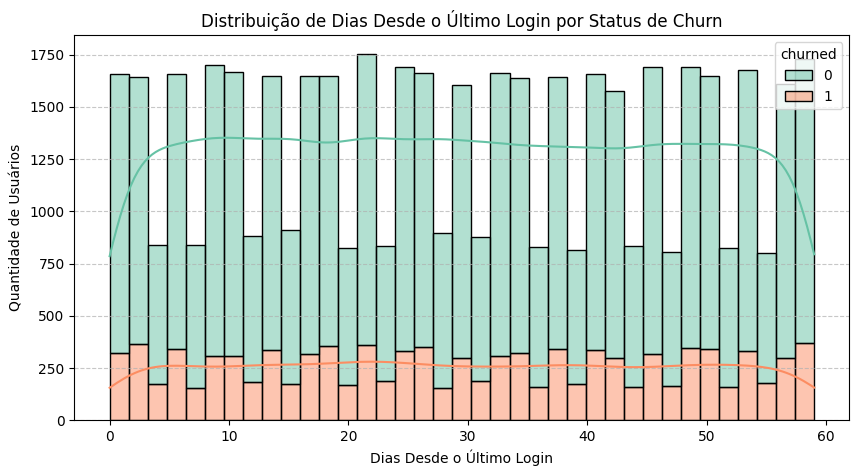

In [ ]:
# Criando o histograma com linha de densidade (kde)
plt.figure(figsize=(10, 5))
sns.histplot(data=dfNetflix, x='days_since_last_login', hue='churned', multiple='stack', kde=True, palette='Set2')

plt.title('Distribuição de Dias Desde o Último Login por Status de Churn')
plt.xlabel('Dias Desde o Último Login')
plt.ylabel('Quantidade de Usuários')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ao analisar o histograma, observa-se que o tempo desde o último login não é um forte indicador isolado de churn. A retenção parece consistente, e o churn ocorre de forma distribuida. No gráfico é possível notar que a faixa de usuários ativos `verde` é consistentemente maior em todos os dias, o que ideica que a maioria dos usuários continuam engajados.

#### BoxPlot

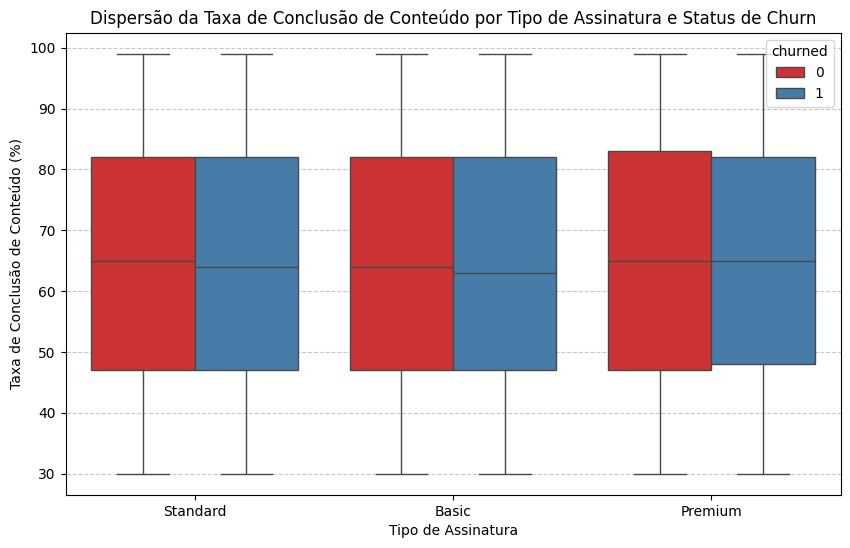

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=dfNetflix, x='subscription_type', y='completion_rate', hue='churned', palette='Set1')
plt.title('Dispersão da Taxa de Conclusão de Conteúdo por Tipo de Assinatura e Status de Churn')
plt.xlabel('Tipo de Assinatura')
plt.ylabel('Taxa de Conclusão de Conteúdo (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O gráfico indica que o comportamento de consumo `conclusão de conteúdo` é consistente entre planos e grupos de churn. Isso sugere que o abandono pode estar mais relacionado a fatores externos, como preço, experiência do usuário ou variedade de conteúdo, do que ao nível de engajamento medido por conclusão.

#### Scatterplot

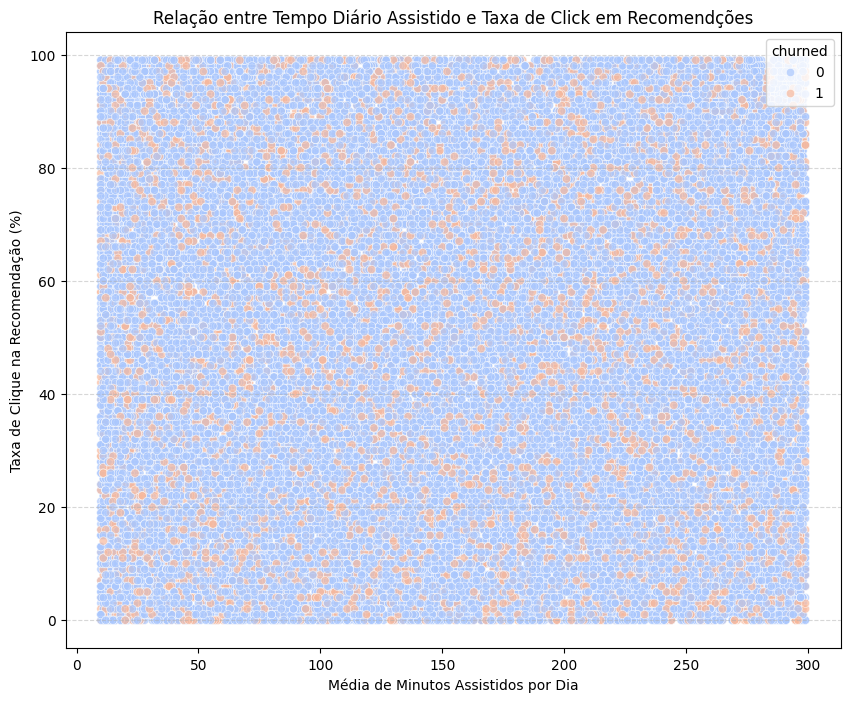

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(data=dfNetflix, x='avg_watch_time_minutes', y='recommendation_click_rate', hue='churned', alpha=0.7, palette='coolwarm')

plt.title('Relação entre Tempo Diário Assistido e Taxa de Click em Recomendções')
plt.xlabel('Média de Minutos Assistidos por Dia')
plt.ylabel('Taxa de Clique na Recomendação (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Alta densidade e dispersão uniforme:**  
* Os pontos estão distribuídos de forma bastante homogênea em todo o plano. Isso indica que não há correlação evidente entre o tempo assistido e a taxa de clique, ou seja, usuários com alta ou baixa taxa de clique podem assistir pouco ou muito tempo por dia.

**Usuários churned:**
* Os pontos laranja ` yes` aparecem espalhados entre os azuis, sem concentração em áreas específicas. O que sugere que o churn não está fortemente associado nem ao tempo assistido nem à taxa de clique.


Nesse caso o gráfico indica que tempo de uso e engajamento com recomendações não são bons preditores isolados de churn. Usuários que abandonam o serviço apresentam padrões de comportamento muito semelhantes aos que permanecem.

#### Matriz de Correlação

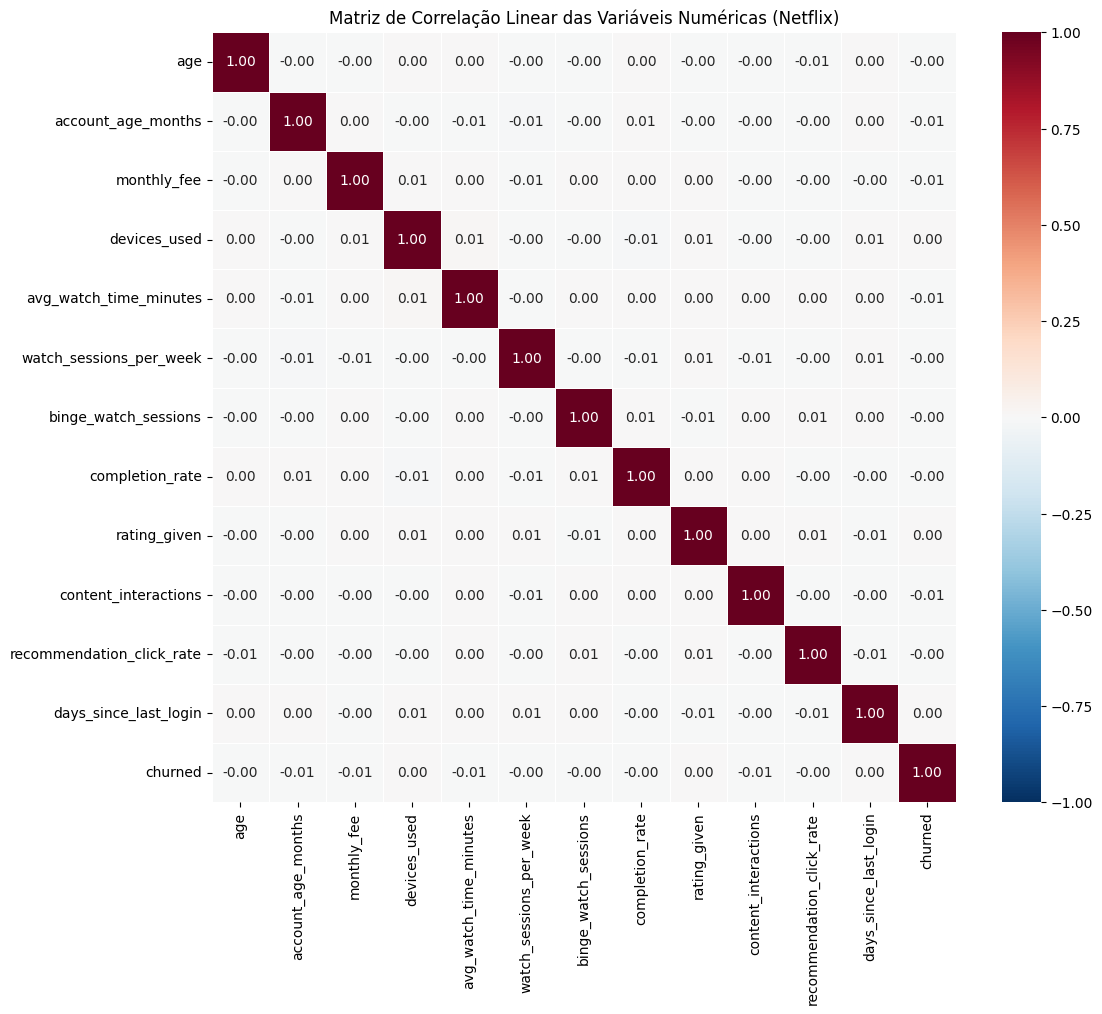

In [ ]:
# Selecionando apenas as colunas numéricas
colunas_numericas = dfNetflix.select_dtypes(include=[np.number])

# Calculando a matriz de correlação de Pearson
matriz_corr = colunas_numericas.corr()

# Plot mapa
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlação Linear das Variáveis Numéricas (Netflix)')
plt.show()

* Quase todos os coeficientes fora da diagonal estão próximos de 0, indicando ausência de relação linear significativa entre as variáveis. Isso significa que, por exemplo, o tempo médio assistido por dia não tem relação direta com o número de dispositivos usados ou com a taxa de cliques em recomendações.
* A falta de correlação entre variáveis como avg_watch_time_minutes, completion_rate e recommendation_click_rate sugere que o engajamento do usuário é multifatorial e não pode ser explicado por uma única métrica.

A matriz revela que os comportamentos dos usuários da Netflix são diversos e independentes, sem correlações lineares marcantes. Isso dá a ideia de que o churn e o engajamento são fenômenos multidimensionais

#### Analisando variáveis categóricas

O cancelamento não é explicado por um único fator isolado, sendo necessário explorar as variáveis categóricas e combinações de fatores.


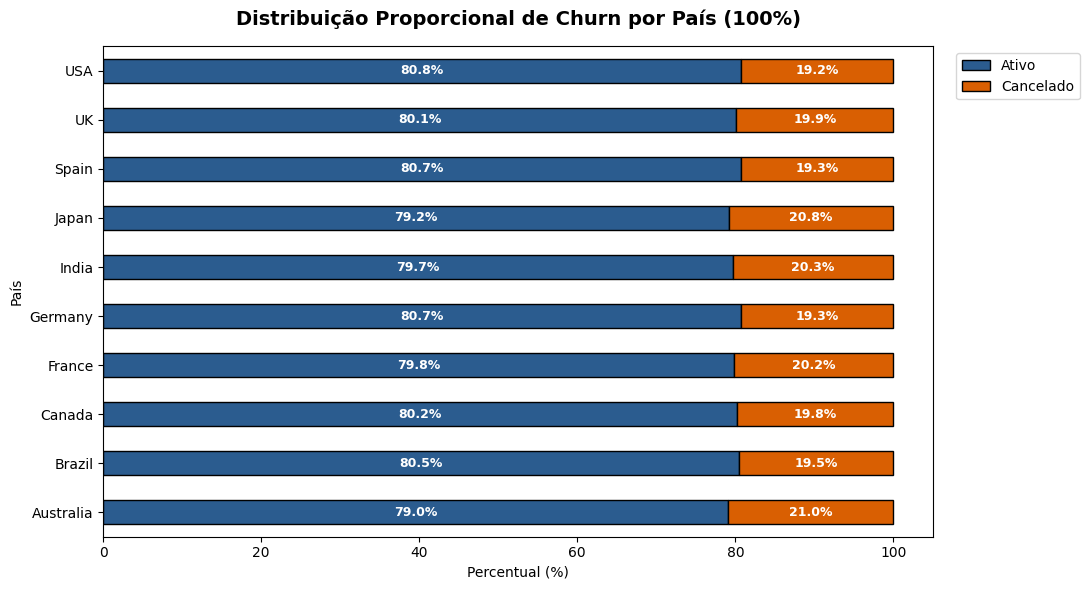

In [ ]:
# Criando a tabela cruzada normalizada por índice (proporção de 0 a 100%)
pais_churn = pd.crosstab(dfNetflix['country'], dfNetflix['churned'], normalize='index') * 100

# Plotando um único gráfico
ax = pais_churn.plot(kind='barh', stacked=True, figsize=(11, 6), color=['#2b5c8f', '#d95f02'], edgecolor='black')

plt.title('Distribuição Proporcional de Churn por País (100%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentual (%)')
plt.ylabel('País')
plt.legend(['Ativo', 'Cancelado'], bbox_to_anchor=(1.02, 1), loc='upper left')

# Adicionando os rótulos de porcentagem dentro das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

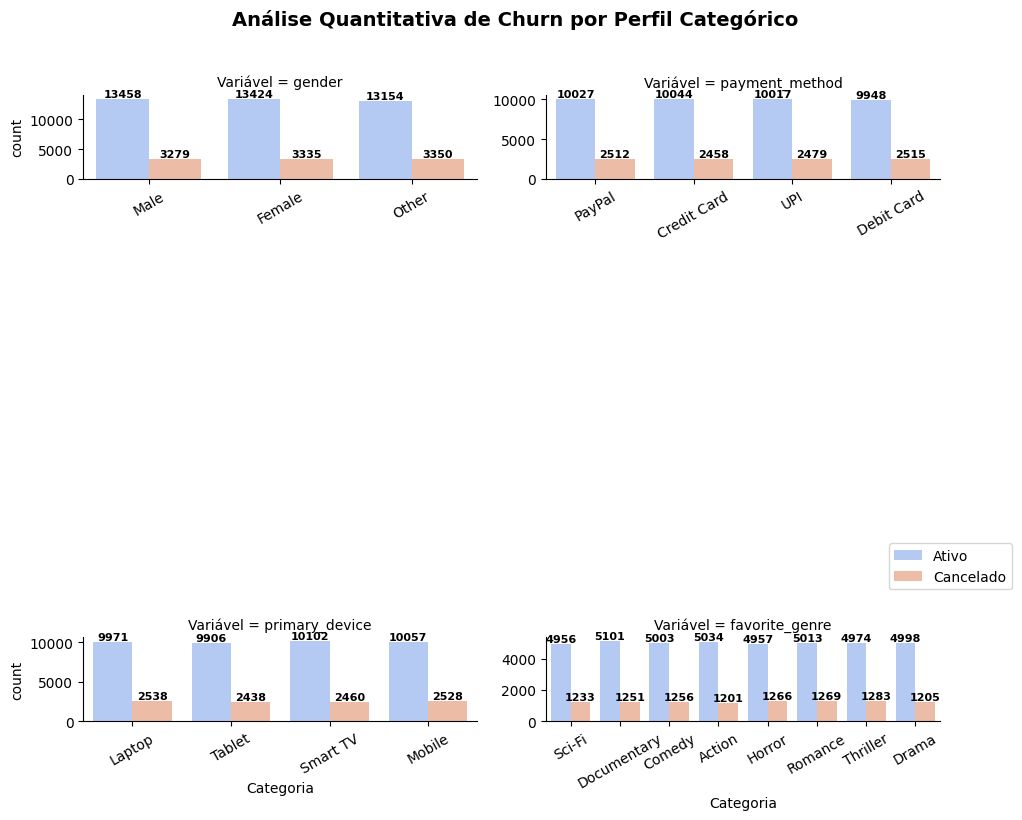

In [ ]:
# Juntando as colunas categóricas em uma estrutura unificada
df_melted = pd.melt(dfNetflix, id_vars=['churned'], value_vars=['gender', 'payment_method', 'primary_device', 'favorite_genre'],
                    var_name='Variável', value_name='Categoria')

# Criando um gráfico facetado nativo do Seaborn
g = sns.catplot(
    data=df_melted, x='Categoria', hue='churned', col='Variável',
    kind='count', col_wrap=2, sharex=False, sharey=False,
    palette='coolwarm', height=4, aspect=1.3, legend=False
)

# Adicionando rótulos de contagem
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fontsize=8, fontweight='bold')

plt.legend(['Ativo', 'Cancelado'], loc='upper right', bbox_to_anchor=(1.2, 2.2))
g.fig.suptitle('Análise Quantitativa de Churn por Perfil Categórico', fontsize=14, fontweight='bold', y=1.02)


plt.tight_layout()
plt.show()

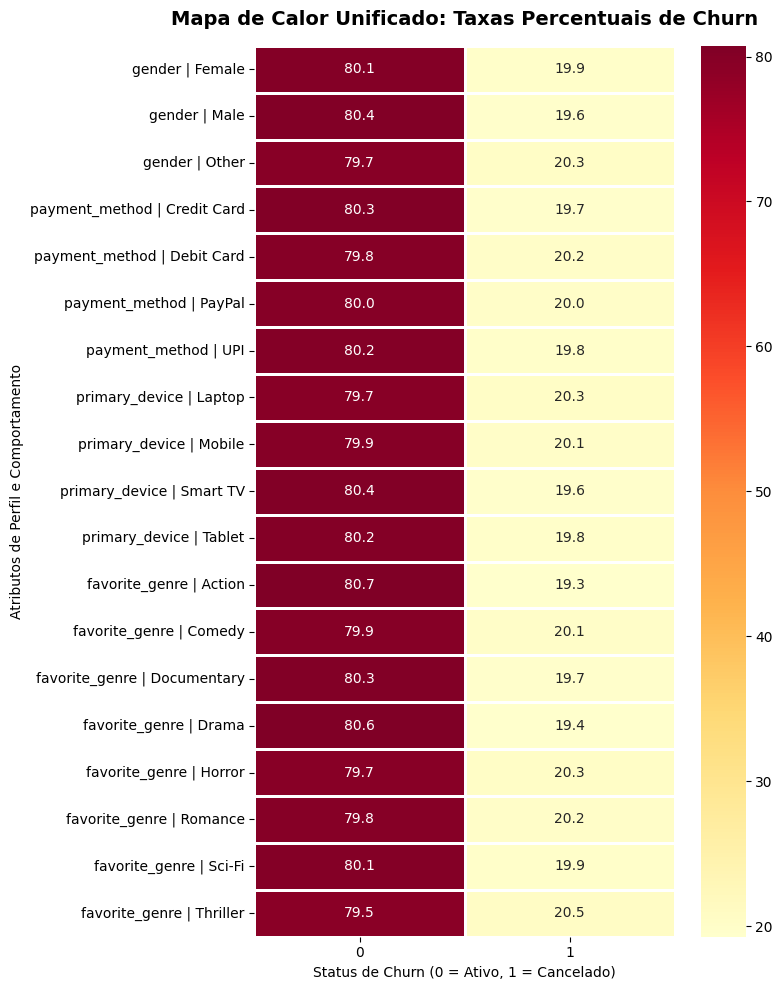

In [ ]:
# Lista de variáveis categóricas
cols_cat = ['gender', 'payment_method', 'primary_device', 'favorite_genre']

# Criando e concatenando as tabelas cruzadas em um único DataFrame
tabelas_unificadas = []
for col in cols_cat:
    ct = pd.crosstab(dfNetflix[col], dfNetflix['churned'], normalize='index') * 100

    ct.index = [f"{col} | {idx}" for idx in ct.index]
    tabelas_unificadas.append(ct)

df_heatmap_unico = pd.concat(tabelas_unificadas)

# Plotando um único mapa de calor
plt.figure(figsize=(8, 10))
sns.heatmap(df_heatmap_unico, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.8, linecolor='white')

plt.title('Mapa de Calor Unificado: Taxas Percentuais de Churn', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Atributos de Perfil e Comportamento')
plt.xlabel('Status de Churn (0 = Ativo, 1 = Cancelado)')


plt.tight_layout()
plt.show()

Como observado nas visualizações unificadas acima, nenhuma variável categórica analisada de forma isolada apresenta uma relação clara ou um gatilho evidente com o cancelamento da assinatura. A distribuição de Churn se mantém praticamente uniforme `em torno de 50% para cada classe` entre gêneros, métodos de pagamento, dispositivos de acesso, gêneros favoritos de conteúdo e até mesmo entre os diferentes países.

Esse comportamento homogêneo indica que o perfil demográfico, a localização geográfica ou as preferências temáticas do assinante, sozinhos, não são fatores determinantes para a evasão.

**Conclusão da Análise**

* Taxa de churn estável, cerca de 20% dos usuários cancelam, independentemente de país, gênero, dispositivo ou método de pagamento.

* Fatores geográficos pouco relevantes, variação mínima entre países (≈19–21%).

* Perfis categóricos homogêneos, gênero, dispositivo principal e gênero favorito não apresentam diferenças significativas.

* Variáveis numéricas independentes, tempo médio assistido, taxa de conclusão e cliques em recomendações não têm correlação linear forte com churn.

* Engajamento distribuído, usuários ativos e churned apresentam padrões semelhantes de uso e interação.

# PARTE 2 - Pré Processamento

In [ ]:
# Separa as variáveis de entrada (features) da variável alvo (target)
X = dfNetflix_processado.drop(columns=['churned'])   # remove a coluna alvo
y = dfNetflix['churned']                  # seleciona apenas a variável alvo

In [ ]:
X

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
0,56,17,15.99,1,220,17,3,60,1.7,5,...,False,False,False,False,False,False,False,False,True,False
1,46,20,12.99,2,76,15,4,71,4.6,7,...,False,False,True,False,True,False,False,False,False,False
2,32,25,15.99,2,215,6,13,33,2.0,27,...,False,False,True,True,False,False,False,False,False,False
3,60,37,12.99,3,280,4,9,58,1.2,9,...,False,True,False,False,False,False,False,False,False,False
4,25,23,12.99,3,261,15,9,64,1.3,49,...,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,60,30,15.99,1,178,19,1,45,1.8,13,...,False,False,True,False,True,False,False,False,False,False
49996,46,39,12.99,3,95,15,5,77,2.1,46,...,False,True,False,True,False,False,False,False,False,False
49997,19,53,7.99,3,118,18,4,44,2.3,26,...,False,False,True,False,False,False,False,False,False,True
49998,43,19,7.99,1,280,2,4,44,2.4,12,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
y

,churned
0,0
1,0
2,0
3,0
4,0
...,...
49995,0
49996,1
49997,0
49998,0


## Separação dos Dados de Treino e teste

In [ ]:
# Utilizando o DataFrame dfNetflix_processado gerado após o One-Hot Encoding
X = dfNetflix_processado.drop(columns=['churned'])   # Remove a coluna alvo
y = dfNetflix_processado['churned']                  # Seleciona apenas a variável alvo

from sklearn.model_selection import train_test_split

# Realiza a divisão mantendo a proporção original das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # Reserva 20% dos dados para teste definitivo
    random_state=42,     # Semente para reprodução
    stratify=y           # Mantém a proporção exata de Churn no treino e teste
)

print(f"Treino original: {X_train.shape} | Teste original: {X_test.shape}")

Treino original: (40000, 38) | Teste original: (10000, 38)


In [ ]:
dfNetflix_processado.isnull().sum()

,0
age,0
account_age_months,0
monthly_fee,0
devices_used,0
avg_watch_time_minutes,0
watch_sessions_per_week,0
binge_watch_sessions,0
completion_rate,0
rating_given,0
content_interactions,0


## Escalonamento dos Dados

In [ ]:
from sklearn.preprocessing import RobustScaler

# Instancia o escalonador robusto a outliers
scaler = RobustScaler()

# Ajusta e transforma as features de treino
X_train_scaled = scaler.fit_transform(X_train)

# Transforma as features de teste com os mesmos parâmetros do treino
X_test_scaled = scaler.transform(X_test)

# Convertendo de volta para DataFrame para manter os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
X_train_scaled

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
918,0.500000,-0.166667,-0.625,0.5,-0.326389,-0.7,-0.375,0.885714,-0.95,-0.32,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
25584,-0.666667,0.700000,0.000,-0.5,-0.784722,-0.1,-0.375,0.000000,-0.15,0.40,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6576,0.583333,-0.133333,0.375,-0.5,0.006944,0.6,-0.375,0.600000,0.40,-0.20,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42636,0.458333,-0.366667,0.000,-0.5,-0.604167,-0.8,-0.375,-0.657143,-0.50,-0.64,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
15997,0.833333,0.566667,0.375,-0.5,0.451389,0.2,-0.375,0.885714,-0.75,-0.56,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33286,-0.791667,0.400000,-0.625,-0.5,-0.131944,-0.5,-0.375,-0.542857,0.60,-0.60,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30528,-0.583333,-0.200000,0.375,0.0,0.645833,-0.8,0.375,0.485714,0.90,-0.44,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21117,0.041667,0.700000,0.375,0.5,-0.388889,-0.6,-0.875,0.628571,-0.15,-0.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18440,-0.708333,0.133333,0.375,0.5,0.222222,-0.1,-0.250,-0.800000,0.55,0.40,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_test_scaled


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
48703,0.166667,-0.266667,-0.625,0.5,-0.861111,0.8,0.250,0.485714,-0.20,-0.48,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7086,0.291667,-0.066667,0.375,-0.5,0.486111,0.2,-0.125,0.371429,0.40,-0.36,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
33316,0.708333,-0.800000,0.000,-0.5,-0.361111,0.7,0.750,-0.171429,0.60,-0.08,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16475,0.583333,0.966667,0.375,-0.5,0.159722,-0.2,-0.250,0.742857,0.30,-0.16,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
15187,-0.750000,0.733333,-0.625,0.0,0.708333,0.2,-0.875,0.028571,0.70,-0.08,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32717,0.083333,0.833333,0.375,0.0,-0.180556,0.9,-0.375,-0.828571,0.80,-0.08,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
14192,-0.875000,0.400000,0.000,-0.5,0.895833,0.4,0.000,-0.085714,0.35,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10106,0.041667,0.366667,-0.625,-0.5,0.819444,-0.3,0.250,-0.742857,0.90,0.80,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
31025,-0.375000,0.333333,-0.625,0.5,-0.694444,-0.9,-0.500,0.228571,0.45,-0.80,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Balanceamento de Classe (smote)

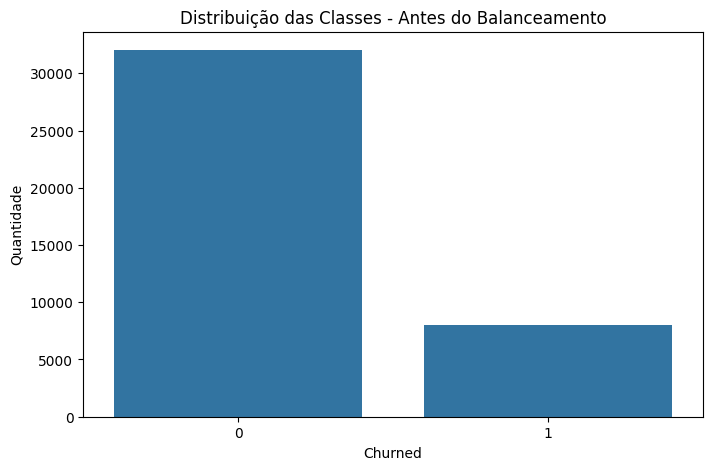

In [ ]:
plt.figure(figsize=(8,5))

# Histograma das classes antes do balanceamento de classes
sns.countplot(x=y_train)

plt.title('Distribuição das Classes - Antes do Balanceamento')
plt.xlabel('Churned')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o SMOTE
smote = SMOTE(random_state=42)

# Aplicando o balanceamento APENAS nos dados escalonados de treino
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Proporção das classes no treino após o SMOTE:")
print(y_train_balanced.value_counts(normalize=True))



Proporção das classes no treino após o SMOTE:
churned
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
print(y_train_balanced.value_counts())

churned
1    32029
0    32029
Name: count, dtype: int64


/tmp/ipykernel_1293/791118061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced, palette='coolwarm', edgecolor='black')


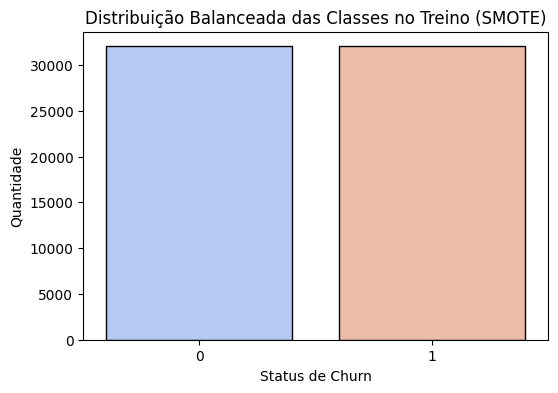

In [ ]:
# Gráfico de validação da distribuição
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_balanced, palette='coolwarm', edgecolor='black')
plt.title('Distribuição Balanceada das Classes no Treino (SMOTE)')
plt.xlabel('Status de Churn')
plt.ylabel('Quantidade')
plt.show()

# PARTE 3 - Modelagem, Otimização Multifatorial e Avaliação

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.9 MB/s eta 0:00:00


### Sintonia de Hiperparâmetros com Optuna (Random Forest)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

def objective_rf(trial):
    modelo = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        random_state=42
    )

    # O modelo aprende com os dados balanceados pelo SMOTE
    modelo.fit(X_train_balanced, y_train_balanced)

    # A predição é feita no X_test original (sem balanceamento)
    y_pred = modelo.predict(X_test_scaled)

    # Otimizando com base no F1-Score em vez de simplesmente Acurácia
    return f1_score(y_test, y_pred)

# Executando o estudo bayesiano
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=25)

print("\nMelhores Hiperparâmetros encontrados pelo Optuna:")
print(study_rf.best_params)

[I 2026-07-07 14:22:00,679] A new study created in memory with name: no-name-85d19868-56ed-4f82-84b1-ab198f9f3e5d
[I 2026-07-07 14:22:38,497] Trial 0 finished with value: 0.016354016354016353 and parameters: {'n_estimators': 89, 'max_depth': 15, 'criterion': 'gini'}. Best is trial 0 with value: 0.016354016354016353.
[I 2026-07-07 14:22:53,349] Trial 1 finished with value: 0.16408491107286288 and parameters: {'n_estimators': 150, 'max_depth': 8, 'criterion': 'gini'}. Best is trial 1 with value: 0.16408491107286288.
[I 2026-07-07 14:23:22,198] Trial 2 finished with value: 0.18773135906927552 and parameters: {'n_estimators': 285, 'max_depth': 7, 'criterion': 'entropy'}. Best is trial 2 with value: 0.18773135906927552.
[I 2026-07-07 14:23:48,979] Trial 3 finished with value: 0.07919191919191919 and parameters: {'n_estimators': 199, 'max_depth': 11, 'criterion': 'gini'}. Best is trial 2 with value: 0.18773135906927552.
[I 2026-07-07 14:24:06,149] Trial 4 finished with value: 0.0883472962680


Melhores Hiperparâmetros encontrados pelo Optuna:
{'n_estimators': 52, 'max_depth': 3, 'criterion': 'entropy'}


### Treinamento e Estatísticas

Acurácia Geral do Modelo: 0.5682

              precision    recall  f1-score   support

   Ativo (0)       0.80      0.61      0.69      8007
 Churned (1)       0.20      0.39      0.26      1993

    accuracy                           0.57     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.68      0.57      0.61     10000



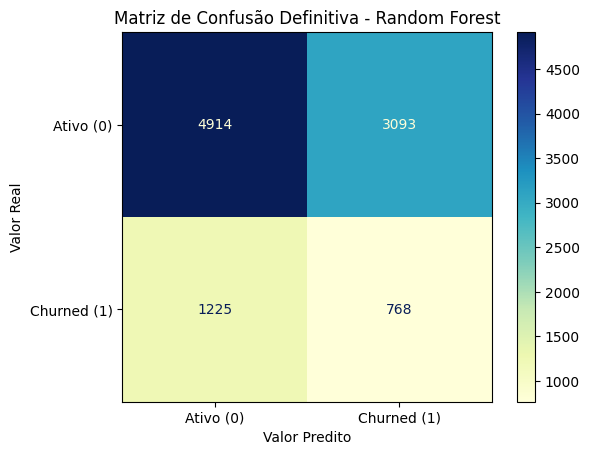

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

# Instanciando o modelo definitivo usando os melhores parâmetros do Optuna
melhor_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

# Treinando na base balanceada pelo SMOTE
melhor_rf.fit(X_train_balanced, y_train_balanced)

# Predição final na base de teste escalonada
y_pred_final = melhor_rf.predict(X_test_scaled)

# Exibição do relatório de classificação formal exigido pelo PDF
classes_netflix = ['Ativo (0)', 'Churned (1)']
print(f"Acurácia Geral do Modelo: {accuracy_score(y_test, y_pred_final):.4f}\n")
print(classification_report(y_test, y_pred_final, target_names=classes_netflix))

# Exibição da Matriz de Confusão
matriz = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=classes_netflix)
disp.plot(cmap='YlGnBu')
plt.title('Matriz de Confusão Definitiva - Random Forest')
plt.xlabel("Valor Predito")
plt.ylabel("Valor Real")
plt.show()

Gráfico mostra como o modelo classificou os dados de teste em relação aos valores reais. Organiza os resultados em quatro quadrantes: os verdadeiros positivos `quando o modelo acerta ao prever churn`, os verdadeiros negativos `quando acerta ao prever ativo`, e os erros falsos positivos `usuários ativos classificados como churned` e falsos negativos `usuários churned classificados como ativos`.

### Validação Cruzada (K-fold)

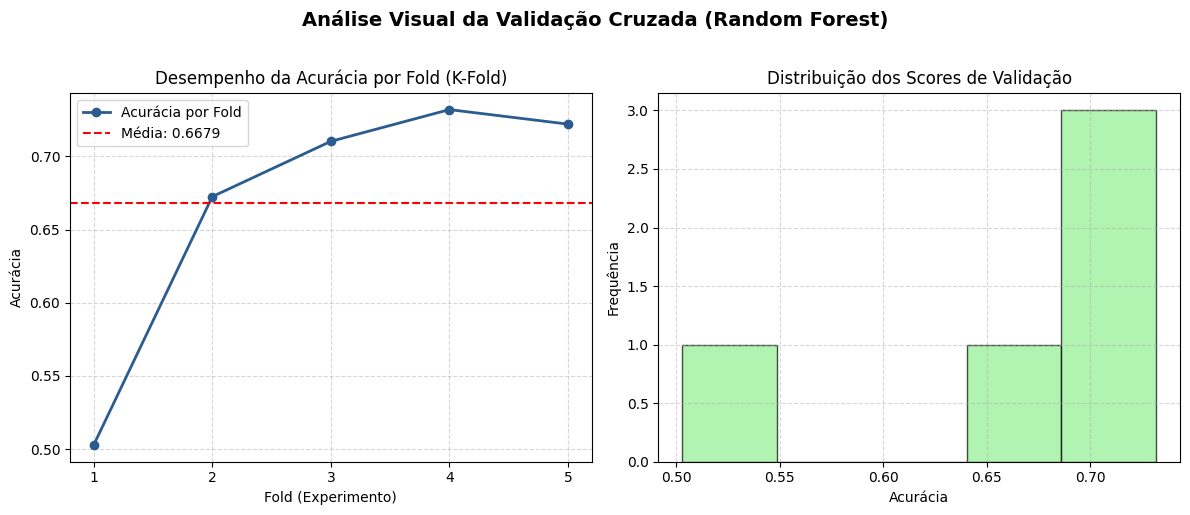

--- Sumário Estatístico da Validação Cruzada ---
Scores em cada Fold: [0.50288792 0.67249454 0.71027162 0.73194911 0.72203575]
Acurácia Média: 0.6679 ± 0.0849


In [ ]:
# Validação cruzada guardando os scores de cada um dos 5 experimentos (folds)
scores_cv = cross_val_score(melhor_rf, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')

# Janela gráfica com dois subplots lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Linha do desempenho por Fold (Experimento)
ax[0].plot(range(1, 6), scores_cv, marker='o', linewidth=2, color='#2b5c8f', label='Acurácia por Fold')
ax[0].axhline(scores_cv.mean(), color='r', linestyle='--', label=f'Média: {scores_cv.mean():.4f}')
ax[0].set_title('Desempenho da Acurácia por Fold (K-Fold)')
ax[0].set_xlabel('Fold (Experimento)')
ax[0].set_ylabel('Acurácia')
ax[0].set_xticks(range(1, 6))
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend()

# Gráfico 2: Histograma/Distribuição dos Scores obtidos
ax[1].hist(scores_cv, bins=5, color='lightgreen', edgecolor='black', alpha=0.7)
ax[1].set_title('Distribuição dos Scores de Validação')
ax[1].set_xlabel('Acurácia')
ax[1].set_ylabel('Frequência')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Análise Visual da Validação Cruzada (Random Forest)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print para apoiar o gráfico
print("--- Sumário Estatístico da Validação Cruzada ---")
print(f"Scores em cada Fold: {scores_cv}")
print(f"Acurácia Média: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")

A função `cross_val_score` calcula a acurácia em cada um dos cinco folds, ou seja, cinco experimentos diferentes em que os dados de treino são divididos em partes distintas. Assim, conseguimos verificar se o modelo mantém desempenho consistente em diferentes subconjuntos dos dados.

Os gráficos ajudam a interpretar esses resultados: o primeiro mostra a acurácia de cada fold em uma linha, junto com a média geral, permitindo ver se há variação significativa entre os experimentos. O segundo é um histograma que mostra a distribuição dessas acurácias, indicando em quais faixas o modelo mais se concentra.

### Avaliação

Acurácia geral: 0.5682 `≈56,8%`

**Matriz de confusão:**

Verdadeiros positivos Churned corretamente: 768

Verdadeiros negativos Ativos corretamente: 4914

Falsos positivos Ativos classificados como churned: 3093

Falsos negativos Churned classificados como ativos: 1225

**Relatório de classificação:**

Classe Ativo (0): precisão 0.80, recall 0.61, F1-score 0.69

Classe Churned (1): precisão 0.20, recall 0.39, F1-score 0.26

Média ponderada: precisão 0.68, recall 0.57, F1-score 0.61

Validação cruzada (5 folds): média de acurácia ≈ 0.6679, indicando desempenho moderado e razoável estabilidade entre os folds.

# Conclusão

**Dificuldades encontradas:**

* Desequilíbrio entre classes, há muito mais usuários ativos que churned.

* Dificuldade do modelo em identificar corretamente os casos de churn, refletida no baixo recall da classe 1.

**Qualidade dos dados:**
* Dados bem estruturados, mas com pouca variabilidade nas variáveis categóricas e baixa correlação entre atributos, o que limita o poder preditivo.

* Mesmo após balanceamento SMOTE, o modelo ainda apresenta viés para a classe majoritária.

**Desempenho do modelo:**

* O Random Forest teve bom desempenho para identificar usuários ativos, mas fraco para prever churn.

* A acurácia geral é aceitável, mas o recall da classe churned indica que o modelo não captura bem os padrões de cancelamento.

**Possíveis melhorias futuras:**

* Testar outros algoritmos XGBoost, LightGBM, redes neurais.

* Ajustar hiperparâmetros com foco em recall e F1-score da classe churned.